<a href="https://colab.research.google.com/github/hsingpei429/ML_marathon/blob/main/Day_001_HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 練習時間
#### 請寫一個函式用來計算 Mean Square Error
$ MSE = \frac{1}{n}\sum_{i=1}^{n}{(Y_i - \hat{Y}_i)^2} $

### Hint: [如何取平方](https://googoodesign.gitbooks.io/-ezpython/unit-1.html)

# [作業目標]
- 仿造範例的MAE函數, 自己寫一個MSE函數(參考上面公式)

# [作業重點]
- 注意程式的縮排
- 是否能將數學公式, 轉換為 Python 的函式組合? (In[2], Out[2])

In [1]:
# 載入基礎套件與代稱
import numpy as np
import matplotlib.pyplot as plt

In [12]:
def mean_absolute_error(y, yp):
    """
    計算 MAE
    Args:
        - y: 實際值
        - yp: 預測值
    Return:
        - mae: MAE
    """
    mae = MAE = sum(abs(y - yp)) / len(y)
    return mae

# 定義 mean_squared_error 這個函數, 計算並傳回 MSE
def mean_squared_error(y, yp):
    """
    請完成這個 Function 後往下執行
    """
    mse = MSE = sum((y - yp) ** 2)/ len(y)
    return mse
    MSE = mean_squared_error(y,y_hat)

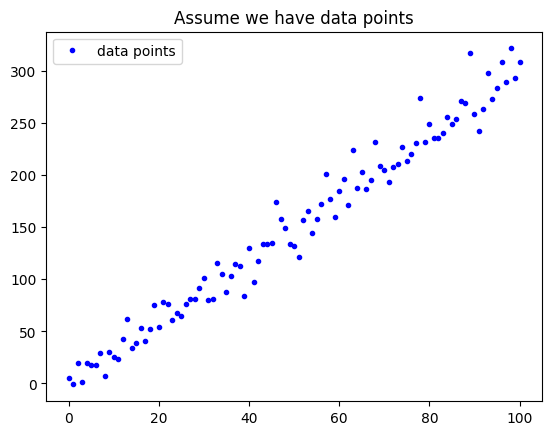

In [13]:
# 與範例相同, 不另外解說
w = 3
b = 0.5
x_lin = np.linspace(0, 100, 101)
y = (x_lin + np.random.randn(101) * 5) * w + b

plt.plot(x_lin, y, 'b.', label = 'data points')
plt.title("Assume we have data points")
plt.legend(loc = 2)
plt.show()

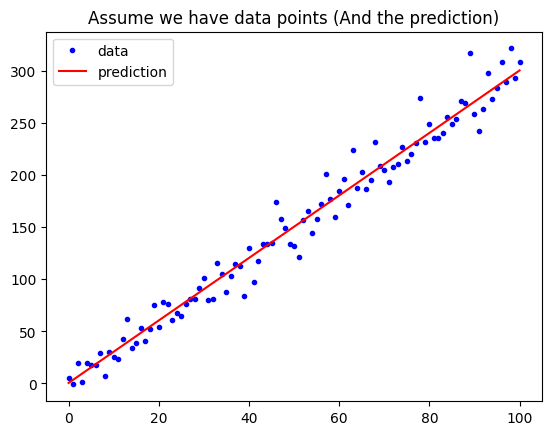

In [14]:
# 與範例相同, 不另外解說
y_hat = x_lin * w + b
plt.plot(x_lin, y, 'b.', label = 'data')
plt.plot(x_lin, y_hat, 'r-', label = 'prediction')
plt.title("Assume we have data points (And the prediction)")
plt.legend(loc = 2)
plt.show()

In [15]:
# 執行 Function, 確認有沒有正常執行
MSE = mean_squared_error(y, y_hat)
MAE = mean_absolute_error(y, y_hat)
print("The Mean squared error is %.3f" % (MSE))
print("The Mean absolute error is %.3f" % (MAE))

The Mean squared error is 212.155
The Mean absolute error is 10.985


# [作業2]

請上 Kaggle, 在 Competitions 或 Dataset 中找一組競賽或資料：Bosch Production Line Performance


1. 你選的這組資料為何重要

在現代高精密製造業（如半導體或大型機電產業）中，哪怕是極微小的瑕疵率都會造成龐大的成本損失。這組資料的重要性在於，它能讓資料科學家利用模型，在零件通過生產線的各個站點時及早預測出「潛在的內部故障」。這不僅有助於即時攔截不良品、減少後續加工的浪費，更能回推找出造成良率下降的根本原因（Root Cause），對整體供應鏈管理與生產流程優化有著極大的實務價值。

2. 資料從何而來 (tips: 譬如提供者是誰、以什麼方式蒐集)
- 提供者： 全球知名的跨國工程與技術公司 Bosch（博世）。

- 蒐集方式： 資料來自 Bosch 實際的裝配生產線。當每一個零件在生產線上移動、經過不同的機台與工作站時，系統會透過感測器與自動化設備，記錄下成千上萬個測量點的數據與時間戳記。

3. 蒐集而來的資料型態為何

這是一組高度結構化的表格型資料，主要以 CSV 格式提供，且特徵維度極高。基於商業機密考量，所有特徵名稱皆已匿名化處理。資料型態主要包含：

- 數值型資料（Numerical Data）： 各工作站感測器測量到的具體參數與數值。

- 類別型資料（Categorical Data）： 零件經過的特定生產路線、機台編號等。

- 時間型資料（Date/Timestamp Data）： 零件到達每個測試點的精確時間。

- 關鍵資料特性： 這組資料在實務上具有極度不平衡（Highly Imbalanced Data） 的特性。在成熟的生產線上，真實發生故障（Defect）的樣本比例極低（僅約 0.5% 左右），這也成了處理此資料時最大的挑戰。

4. 這組資料想解決的問題如何評估

此競賽的目標是預測零件是否會發生故障（二元分類問題）。在評估指標上，因為資料具有極度不平衡的特性，主辦方沒有採用常見的準確率（Accuracy），而是使用了 馬修斯相關係數（Matthews Correlation Coefficient, MCC）。

- 評估邏輯： 在高度不平衡的資料中，如果使用準確率，模型只要盲目預測所有零件都「無故障」，就能輕易獲得 99.5% 的極高準確率，但這在實務上毫無用處。MCC 綜合考量了真陽性（TP）、真陰性（TN）、偽陽性（FP）與偽陰性（FN），能夠更平衡且客觀地衡量分類器在少數樣本上的真實預測能力。分數範圍從 -1（完全預測錯誤）到 +1（完美預測），0 則代表無優於隨機猜測的預測能力
# [作業3]

想像你經營一個自由載客車隊，你希望能透過數據分析以提升業績，請你思考並描述你如何規劃整體的分析/解決方案：

1. 核心問題為何 (tips：如何定義 「提升業績 & 你的假設」)

要提升業績，我們必須先將「業績」拆解為可量化的營運指標。對於車隊而言，最大化利潤的公式是提高總收入並降低營運成本（如油耗與折舊）。因此，我將核心目標定義為：最大化車輛的「載客稼動率」（Utilization Rate），並最小化「空車巡迴時間」（Empty Cruising Time）。

- 核心問題： 如何在對的時間，將對的車輛派往對的地點，以無縫接軌乘客需求？

- 我的假設：

  - 需求具備時空規律性： 乘客叫車需求高度受時間（如上下班尖峰）、地點（如商業區、捷運站）、天氣（如突降大雨）及特殊事件（如演唱會散場）影響。

  - 熱區預測能降低空車率： 若能透過歷史模型預測未來的「叫車熱區」，並提前引導空車前往，就能顯著減少司機漫無目的的空轉，進而提升每小時平均營收（Revenue Per Hour）。

2. 資料從何而來 (tips：哪些資料可能會對你想問的問題產生影響 & 資料如何蒐集)

- 內部營運資料 (透過車載機與叫車 App 自動紀錄)：

  - 派遣與軌跡紀錄： 車輛即時 GPS 定位、司機上線時間、空車與載客狀態切換的時間戳記。

  - 交易與乘車紀錄： 乘客上車與下車的經緯度、乘車距離、行車時間、最終車資、付款方式。

- 外部環境資料 (透過爬蟲與第三方 API 串接)：

  - 天氣資料： 氣象署即時 API（降雨量、氣溫），因天氣驟變往往是短時間需求激增的主因。

  - 交通與路況資料： Google Maps API 或政府交通資料，紀錄各路段的即時壅塞程度。

  - 事件與行事曆： 爬取大型展演場館（如小巨蛋、大巨蛋）的活動時刻表，以及國定假日的行事曆。


3. 蒐集而來的資料型態為何

這些資料具備高度的多樣性，在進入機器學習模型前需要經過大量的清理與特徵工程（Feature Engineering）。主要型態如下：

| 資料型態 | 具體範例 | 分析用途 |
| :--- | :--- | :--- |
| **空間資料 (Geospatial)** | 上下車的經緯度 (Lat, Lng)、車輛 GPS 軌跡 | 聚類分析（Clustering），找出真實的叫車熱點（如 Hexagon 網格劃分）。 |
| **時間序列 (Time-Series)** | 每15分鐘為一個單位的叫車總量、乘車時間戳記 | 捕捉需求的週期性（日週期、週週期），用於時間序列預測模型。 |
| **數值資料 (Numerical)** | 行駛距離 (km)、行車時間 (min)、車資、降雨量 (mm) | 評估單趟利潤率，以及天氣變數對叫車量的量化影響。 |
| **類別資料 (Categorical)** | 星期幾、是否為假日、天氣狀態（晴/雨）、司機 ID | 作為預測模型的虛擬變數（Dummy Variables），控制不同情境。 |


4. 你要回答的問題，其如何評估 (tips：你的假設如何驗證)

當預測模型（例如：隨機森林或 XGBoost）建置完成，並透過 App 推薦司機前往「潛在熱區」後，我們必須嚴謹地評估這套方案是否真的能提升業績。

**評估方法：線上 A/B 測試 (A/B Testing)**

不能只看整體營收上升就歸功於系統，因為這可能是季節性因素（如遇到梅雨季本來生意就比較好）。我會採用以下實驗設計：

1.  **實驗分組：** 隨機將車隊司機分為兩組。
    *   **控制組 (Control Group)：** 維持原狀，司機依靠自身經驗在街上巡迴或等待派單。
    *   **實驗組 (Treatment Group)：** 司機的 App 會顯示「熱區預測地圖」，引導他們前往高潛力區域。
2.  **核心追蹤指標 (KPIs)：**
    *   **載客稼動率：** 載客行駛總時間 / 司機實際上線總時間（預期實驗組要顯著提升）。
    *   **每小時平均營收：** 總車資 / 司機實際上線時數。
3.  **顯著性檢定：** 在運行 2 到 4 週後，收集兩組司機的數據，進行統計檢定（如 t-test）。如果實驗組的每小時平均營收顯著高於控制組，且空車時間顯著下降，這就證明了「需求預測與動態派遣」的假設成立，這套解決方案能實質帶來業績增長。